# 🛍️ NovaMart Customer Analytics

---

## 📦 Dataset Description

 **NovaMart** — a UAE-based omnichannel retailer

| File | Description |
|------|-------------|
| `customers.csv` | Customer profile data — demographics, acquisition channel, loyalty tier |
| `transactions.csv` | Transaction records — purchases, order values, product categories |


---
# 📦 Setup



In [ ]:
# ── Standard imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime
import warnings

warnings.filterwarnings('ignore')

# ── Plot styling ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('✅ All libraries loaded successfully')
print(f'   pandas  version: {pd.__version__}')
print(f'   numpy   version: {np.__version__}')

✅ All libraries loaded successfully
   pandas  version: 2.2.2
   numpy   version: 2.0.2


---
# 📂 Section 1 — Data Loading & Inspection
---

## 1.1 — Load the Datasets

In [ ]:
customers = pd.read_csv('customers.csv')
transactions = pd.read_csv('transactions.csv')

print('customers shape   :', customers.shape)
print('transactions shape:', transactions.shape)

customers shape   : (500, 7)
transactions shape: (2215, 6)


## 1.2 — Inspect the Customers Dataset


In [ ]:
customers.head()

,customer_id,signup_date,region,gender,age_group,acquisition_channel,loyalty_tier
0,C0001,2023-10-17,Abu Dhabi,Female,18-24,Email,Bronze
1,C0002,2022-04-25,Cairo,Female,35-44,Google Search,Bronze
2,C0003,2022-01-26,Sharjah,Male,45-54,Instagram,Gold
3,C0004,2022-10-09,Abu Dhabi,Female,35-44,Google Search,Bronze
4,C0005,2022-09-08,Dubai,Female,45-54,Google Search,Bronze


In [ ]:
#  Data types and non-null counts

customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   signup_date          500 non-null    object
 2   region               500 non-null    object
 3   gender               500 non-null    object
 4   age_group            480 non-null    object
 5   acquisition_channel  500 non-null    object
 6   loyalty_tier         480 non-null    object
dtypes: object(7)
memory usage: 27.5+ KB


In [ ]:
# Statistical summary

customers.describe()

,customer_id,signup_date,region,gender,age_group,acquisition_channel,loyalty_tier
count,500,500,500,500,480,500,480
unique,500,355,5,2,5,6,4
top,C0500,2022-09-29,Dubai,Male,25-34,Instagram,Bronze
freq,1,5,179,253,143,141,211


## 1.3 — Inspect the Transactions Dataset

In [ ]:
# ── Task 1.3a — First 5 rows ──────────────────────────────────────────────────

transactions.head()

,transaction_id,customer_id,date,order_value,product_category,is_return
0,T01467,C0061,2023-12-10,121.37,Home & Living,False
1,T01419,C0124,2023-12-14,110.28,Beauty,False
2,T00582,C0155,2024-02-10,40.69,Clothing,False
3,T01518,C0111,2024-02-17,43.91,Electronics,True
4,T01232,C0171,2024-03-31,89.74,Home & Living,False


In [ ]:
# Data types and non-null counts

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    2215 non-null   object 
 1   customer_id       2215 non-null   object 
 2   date              2215 non-null   object 
 3   order_value       2215 non-null   float64
 4   product_category  2149 non-null   object 
 5   is_return         2215 non-null   bool   
dtypes: bool(1), float64(1), object(4)
memory usage: 88.8+ KB


In [ ]:
# Statistical summary

transactions.describe()

,order_value
count,2215.000000
mean,154.092515
std,545.212926
min,10.000000
25%,49.870000
50%,87.080000
75%,156.495000
max,12000.000000


## 1.4 — Missing Values & Duplicates Check

In [ ]:
# Missing values
print('=== CUSTOMERS — Missing Values ===')
print(customers.isnull().sum())

print('\n=== TRANSACTIONS — Missing Values ===')
print(transactions.isnull().sum())

print('\n=== Duplicate Rows ===')
print('Customers duplicates  :', customers.duplicated().sum())
print('Transactions duplicates:', transactions.duplicated().sum())

=== CUSTOMERS — Missing Values ===
customer_id             0
signup_date             0
region                  0
gender                  0
age_group              20
acquisition_channel     0
loyalty_tier           20
dtype: int64

=== TRANSACTIONS — Missing Values ===
transaction_id       0
customer_id          0
date                 0
order_value          0
product_category    66
is_return            0
dtype: int64

=== Duplicate Rows ===
Customers duplicates  : 0
Transactions duplicates: 15


---
# 🧹 Section 2 — Data Cleaning
---

## 2.1 — Fix Date Columns


In [ ]:
# Convert date columns to datetime

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
transactions['date'] = pd.to_datetime(transactions['date'])

# Verify the conversion worked
print('customers  date dtype  :', customers['signup_date'].dtype)
print('transactions date dtype:', transactions['date'].dtype)

customers  date dtype  : datetime64[ns]
transactions date dtype: datetime64[ns]




We converted customers.signup_date and transactions.date from object type to proper datetime format using pd.to_datetime(). This is necessary because time-based analysis, monthly revenue trends, and RFM recency calculations require valid datetime fields. Without this conversion, date operations would be unreliable or unavailable.

##2.2 — Handle Missing Values

In [ ]:
# Handle missing values in customers dataset

customers['age_group'] = customers['age_group'].fillna(customers['age_group'].mode()[0])
customers['loyalty_tier'] = customers['loyalty_tier'].fillna(customers['loyalty_tier'].mode()[0])

# Handle missing values in transactions dataset
transactions['product_category'] = transactions['product_category'].fillna('Unknown')

# Verify — should show 0 for all columns
print('Remaining nulls in customers:')
print(customers.isnull().sum())
print('\nRemaining nulls in transactions:')
print(transactions.isnull().sum())

Remaining nulls in customers:
customer_id            0
signup_date            0
region                 0
gender                 0
age_group              0
acquisition_channel    0
loyalty_tier           0
dtype: int64

Remaining nulls in transactions:
transaction_id      0
customer_id         0
date                0
order_value         0
product_category    0
is_return           0
dtype: int64




> age_group → filled with the mode because it is a categorical customer attribute and only a small number of values were missing.
loyalty_tier → filled with the mode because it is also a categorical variable and using the most common tier avoids dropping customer records.
product_category → filled with "Unknown" because dropping transaction rows would reduce total revenue and distort product-level analysis.


## 2.3 — Remove Duplicate Rows


In [ ]:
before_customers     = len(customers)
before_transactions  = len(transactions)

customers = customers.drop_duplicates()
transactions = transactions.drop_duplicates()

print(f'Customers    removed: {before_customers - len(customers)} rows')
print(f'Transactions removed: {before_transactions - len(transactions)} rows')

Customers    removed: 0 rows
Transactions removed: 15 rows


## 2.4 — Remove Returns


In [ ]:
# Filter out returned transactions

before = len(transactions)

transactions = transactions[transactions['is_return'] == False]

print(f'Rows before: {before}')
print(f'Rows after : {len(transactions)}')
print(f'Returns removed: {before - len(transactions)}')

Rows before: 2200
Rows after : 2027
Returns removed: 173




>We remove returned transactions because they do not represent real completed purchases or retained revenue. If returns are included, customer frequency and monetary value will be overstated, which makes the RFM segmentation inaccurate and can place customers into the wrong segment

## 2.5 — Remove Outliers in Order Value

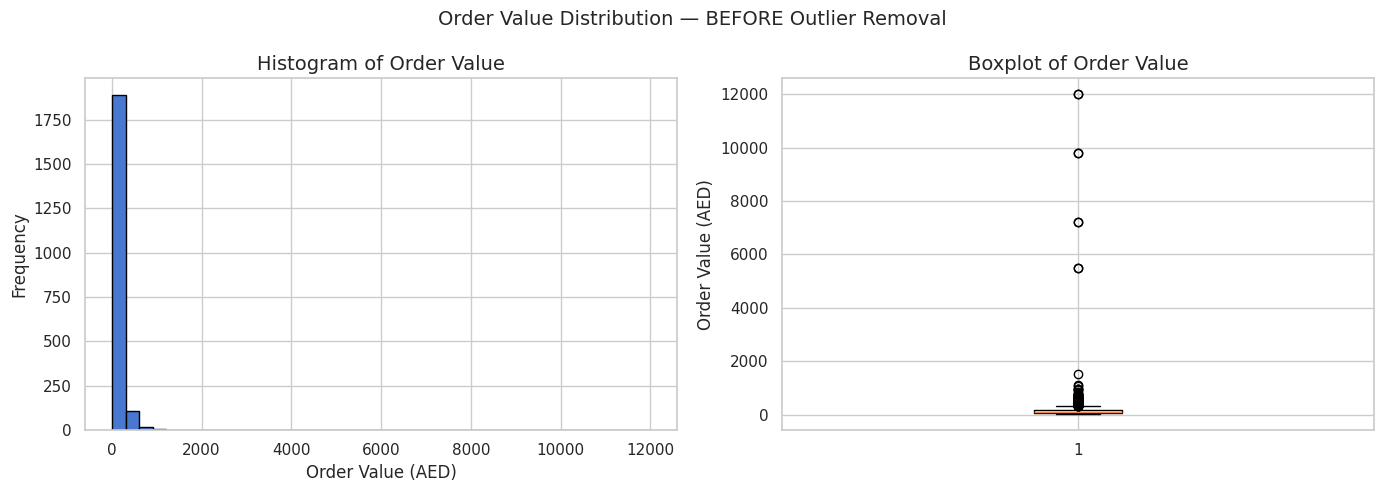

In [ ]:
# Step 1: Plot the distribution BEFORE removing outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(transactions['order_value'], bins=40, edgecolor='black')
axes[0].set_title('Histogram of Order Value')
axes[0].set_xlabel('Order Value (AED)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(transactions['order_value'], vert=True)
axes[1].set_title('Boxplot of Order Value')
axes[1].set_ylabel('Order Value (AED)')

plt.suptitle('Order Value Distribution — BEFORE Outlier Removal', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Calculate IQR bounds

Q1  = transactions['order_value'].quantile(0.25)
Q3  = transactions['order_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1           : {Q1:.2f}')
print(f'Q3           : {Q3:.2f}')
print(f'IQR          : {IQR:.2f}')
print(f'Lower bound  : {lower_bound:.2f}')
print(f'Upper bound  : {upper_bound:.2f}')

# Step 3: Filter out outliers
before = len(transactions)

transactions = transactions[
    (transactions['order_value'] >= lower_bound) &
    (transactions['order_value'] <= upper_bound)
]

print(f'\nOutliers removed: {before - len(transactions)} rows')

Q1           : 50.28
Q3           : 156.28
IQR          : 106.00
Lower bound  : -108.71
Upper bound  : 315.27

Outliers removed: 136 rows


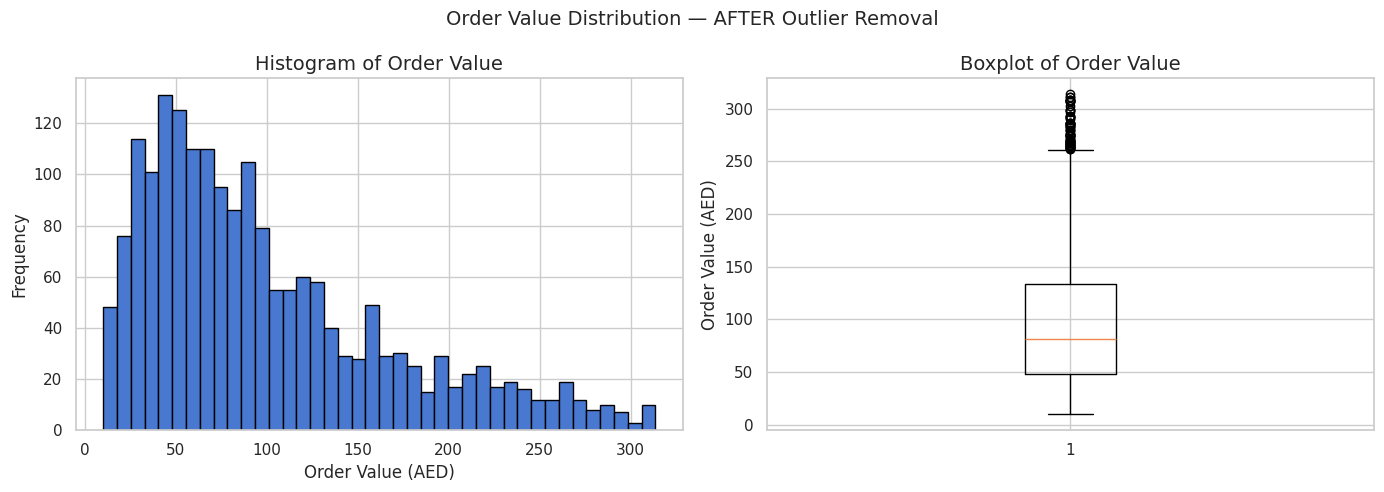

In [ ]:
# Step 4: Plot the distribution AFTER removing outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(transactions['order_value'], bins=40, edgecolor='black')
axes[0].set_title('Histogram of Order Value')
axes[0].set_xlabel('Order Value (AED)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(transactions['order_value'], vert=True)
axes[1].set_title('Boxplot of Order Value')
axes[1].set_ylabel('Order Value (AED)')

plt.suptitle('Order Value Distribution — AFTER Outlier Removal', fontsize=14)
plt.tight_layout()
plt.show()



>Before outlier removal, the distribution of order values was highly right-skewed, with a few extreme transactions stretching the scale and compressing the main body of the data. After applying the IQR method, the histogram became more concentrated around typical order values and the boxplot showed a much tighter spread. This makes the dataset more representative of normal customer purchasing behaviour and reduces the distortion caused by unusually large orders

## 2.6 — Merge the Datasets


In [ ]:
# Merge on customer_id using a LEFT join
df = transactions.merge(customers, on='customer_id', how='left')

print('Merged dataset shape:', df.shape)
df.head()

Merged dataset shape: (1891, 12)


,transaction_id,customer_id,date,order_value,product_category,is_return,signup_date,region,gender,age_group,acquisition_channel,loyalty_tier
0,T01467,C0061,2023-12-10,121.37,Home & Living,False,2022-07-16,Abu Dhabi,Female,45-54,Google Search,Bronze
1,T01419,C0124,2023-12-14,110.28,Beauty,False,2023-08-22,Dubai,Female,45-54,TikTok,Bronze
2,T00582,C0155,2024-02-10,40.69,Clothing,False,2022-10-01,Cairo,Male,35-44,Instagram,Bronze
3,T01232,C0171,2024-03-31,89.74,Home & Living,False,2023-10-17,Sharjah,Male,35-44,Google Search,Silver
4,T01519,C0388,2024-03-11,53.39,Clothing,False,2023-09-19,Dubai,Male,18-24,Instagram,Silver



> We use a LEFT join to keep all cleaned transaction records in the final merged dataset. This is important because transactions are the main unit of analysis for revenue, EDA, and RFM calculations. An INNER join could accidentally remove valid transactions if any customer record were missing or unmatched.

---
# 📊 Section 3 — Exploratory Data Analysis (EDA)

## 3.1 — Revenue Over Time


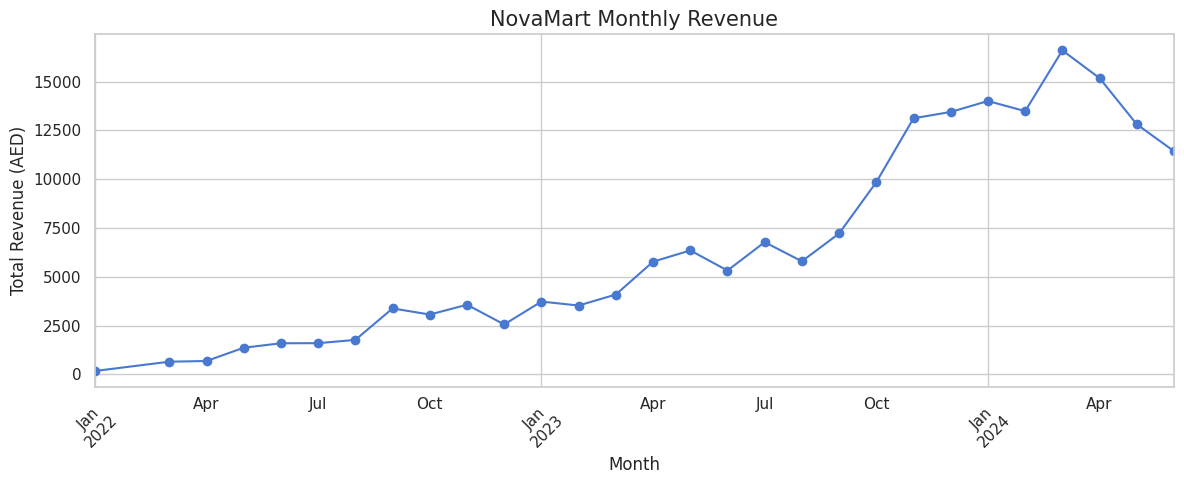

In [ ]:
# Hint: group by year-month period, sum order_value, then plot
monthly_revenue = df.groupby(df['date'].dt.to_period('M'))['order_value'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(marker='o')

plt.title('NovaMart Monthly Revenue', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (AED)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



> NovaMart’s revenue shows a clear overall upward trend over time, especially from late 2023 into early 2024. The strongest growth appears in the final months, with a major peak around March 2024, while the earliest months in 2022 had the lowest revenue levels. This pattern suggests that the business is growing, and the spikes may be linked to seasonal shopping periods, successful promotions, or stronger customer acquisition and retention in late 2023 and early 2024

## 3.2 — Revenue by Product Category

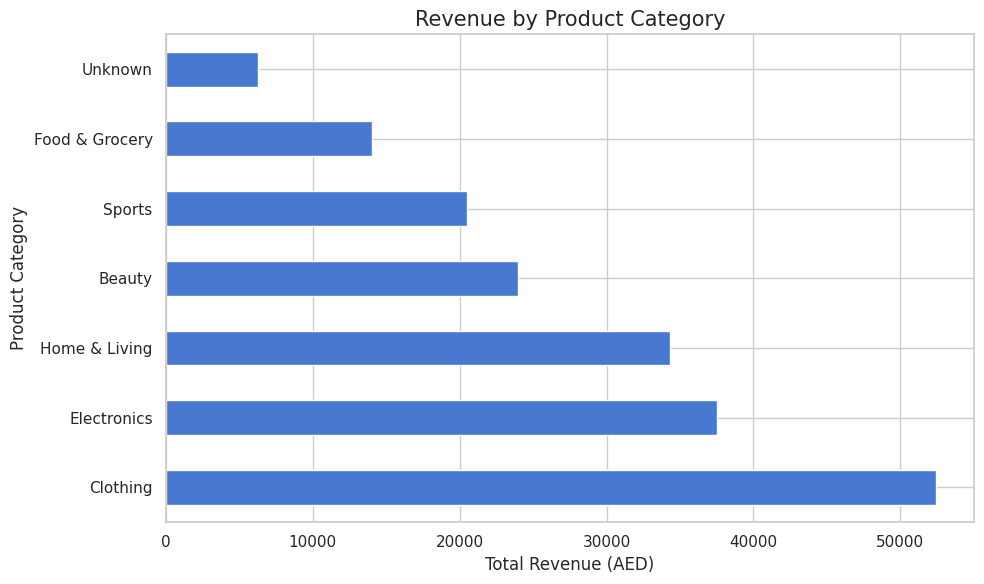

In [ ]:
# Group by product_category, sum order_value, sort descending

category_revenue = df.groupby('product_category')['order_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_revenue.plot(kind='barh')
# Hint: use .plot(kind='barh') or sns.barplot with orient='h'
plt.title('Revenue by Product Category', fontsize=15)
plt.xlabel('Total Revenue (AED)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


> Clothing is the top-performing category by total revenue, clearly ahead of Electronics, which appears to be in second place. The weakest category is Unknown, but among the defined categories, Food & Grocery generates the lowest revenue and may be underperforming due to lower demand, weaker positioning, or a smaller average basket size. If NovaMart had to reduce marketing spend in one category, Food & Grocery would be the most reasonable candidate, because it contributes the least revenue among the clearly identified product groups.

## 3.3 — Customer Acquisition by Channel


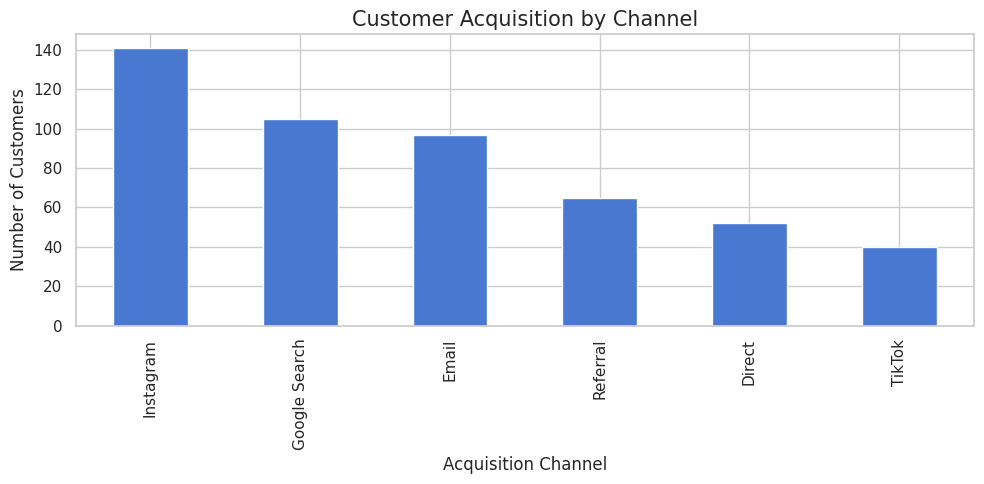

In [ ]:
# Use the customers dataframe
channel_counts = customers['acquisition_channel'].value_counts()

plt.figure(figsize=(10, 5))
channel_counts.plot(kind='bar')

plt.title('Customer Acquisition by Channel', fontsize=15)
plt.xlabel('Acquisition Channel')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()



> instagram brings in the highest number of customers, followed by Google Search and Email. However, a high customer volume from one channel does not necessarily mean it is the best channel, because those customers may have lower spending, weaker retention, or lower lifetime value than customers from other channels. To properly evaluate channel quality, NovaMart would also need revenue by channel, repeat purchase rate, average order value, and ideally customer lifetime value and acquisition cost

## 3.4 — Order Value Distribution


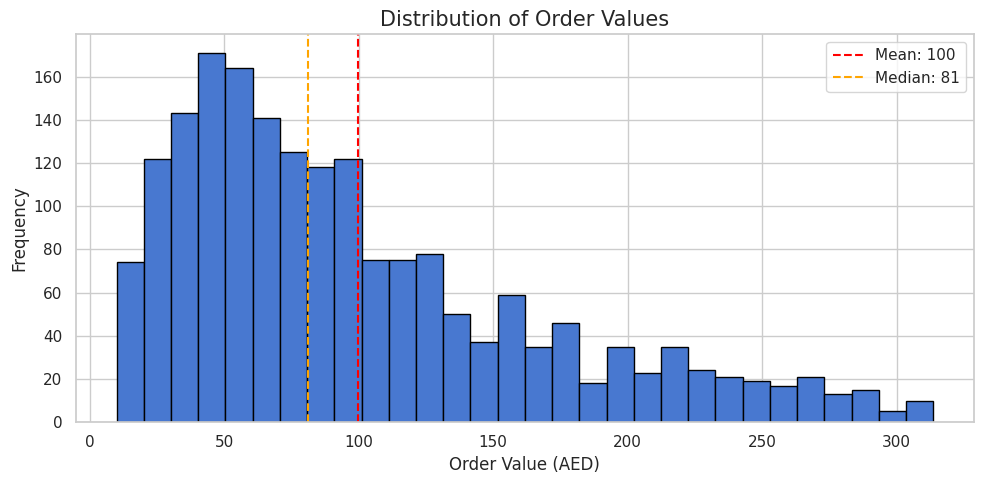

Mean   order value: 99.94 AED
Median order value: 81.35 AED
Std    order value: 68.06 AED


In [ ]:

mean_value   = df['order_value'].mean()
median_value = df['order_value'].median()

plt.figure(figsize=(10, 5))
plt.hist(df['order_value'], bins=30, edgecolor='black')

# Add vertical lines for mean and median
plt.axvline(mean_value,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_value:.0f}')
plt.axvline(median_value, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_value:.0f}')

plt.title('Distribution of Order Values', fontsize=15)
plt.xlabel('Order Value (AED)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean   order value: {mean_value:.2f} AED')
print(f'Median order value: {median_value:.2f} AED')
print(f'Std    order value: {df["order_value"].std():.2f} AED')



> The distribution of order values is positively skewed, with most transactions concentrated at lower and mid-range values and a smaller number of higher-value orders extending the right tail. The mean order value is higher than the median, which shows that a limited number of larger purchases are pulling the average upward. This suggests that most NovaMart customers make moderate purchases, so the company could use one strategy to increase basket size among typical buyers and another to retain and upsell higher-value customers

## 3.5 — Average Order Value by Age Group


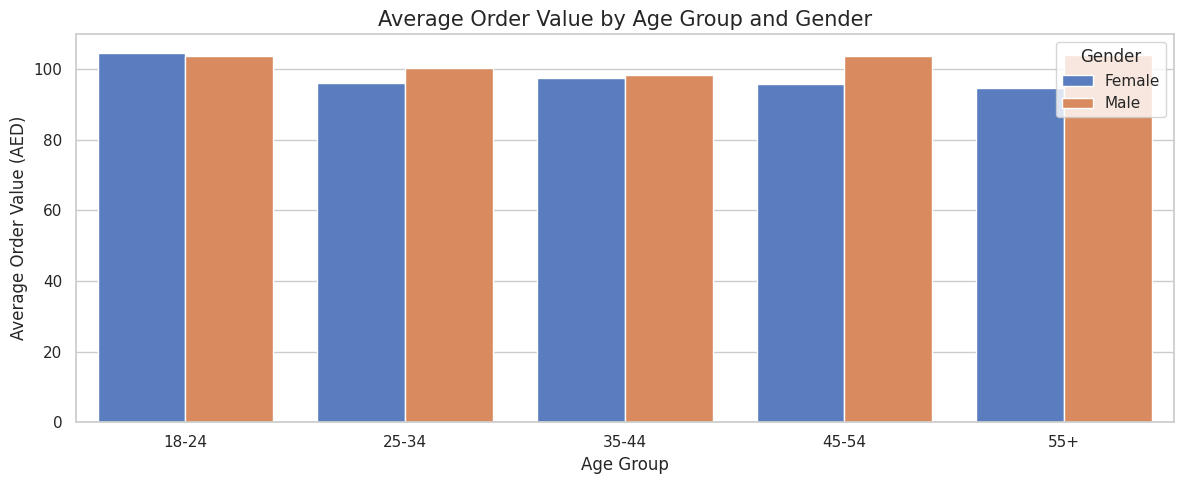

In [ ]:
# Group by age_group and gender, calculate mean order_value

age_gender_aov = df.groupby(['age_group', 'gender'], as_index=False)['order_value'].mean()

plt.figure(figsize=(12, 5))
sns.barplot(data=age_gender_aov, x='age_group', y='order_value', hue='gender')

plt.title('Average Order Value by Age Group and Gender', fontsize=15)
plt.xlabel('Age Group')
plt.ylabel('Average Order Value (AED)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


> the highest average order value appears among female customers aged 18–24, although the difference from several male age groups is relatively small. In general, male customers tend to have a slightly higher average order value than females in most age groups, especially in the older segments. This suggests that NovaMart can use more targeted demographic campaigns, with premium or upsell offers aimed at the age-gender combinations that show the strongest spending per transaction


---
# 🎯 Section 4 — RFM Segmentation
### *30 marks*

RFM (Recency, Frequency, Monetary) is one of the most widely used customer segmentation frameworks in marketing analytics.

- **Recency** — how many days since the customer's last purchase (lower = better)
- **Frequency** — how many times the customer has purchased
- **Monetary** — how much total money the customer has spent

---

## 4.1 — Calculate RFM Values


In [ ]:
# Set the snapshot date as 1 day after the most recent transaction
snapshot_date = df['date'].max() + pd.Timedelta(days=1)
print('Snapshot date:', snapshot_date)

# Recency   = days between snapshot_date and the customer's most recent purchase
# Frequency = total number of transactions
# Monetary  = total order value

rfm = df.groupby('customer_id').agg(
    recency=('date', lambda x: (snapshot_date - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('order_value', 'sum')
).reset_index()

print(f'\nRFM table shape: {rfm.shape}')
rfm.head(10)

Snapshot date: 2024-07-01 00:00:00

RFM table shape: (335, 4)


,customer_id,recency,frequency,monetary
0,C0004,325,2,76.01
1,C0009,100,1,90.99
2,C0012,31,3,311.80
3,C0013,99,3,297.36
4,C0014,129,3,312.93
5,C0015,228,5,375.99
6,C0016,1,1,116.40
7,C0017,23,10,685.50
8,C0019,58,5,371.62
9,C0021,208,2,173.44




> We use snapshot_date instead of today’s real date so that recency is calculated consistently from the perspective of the dataset itself. This makes the analysis reproducible for every student, while using today’s actual date would make recency values change over time and distort the RFM results


## 4.2 — Score Each RFM Dimension


In [ ]:
# IMPORTANT: For Recency, score 5 = most recent (lowest days), 1 = least recent
#            For Frequency and Monetary, score 5 = highest, 1 = lowest

# Recency Score (note reversed labels — lower days = higher score)
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]   # reversed because lower recency = better
)

# Frequency Score
# Hint: use rank(method='first') to handle ties
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary Score
rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Combine into a single RFM string score (e.g. '543')
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm[['customer_id','recency','frequency','monetary',
     'R_score','F_score','M_score','RFM_Score']].head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score
0,C0004,325,2,76.01,1,2,1,121
1,C0009,100,1,90.99,3,1,1,311
2,C0012,31,3,311.80,4,2,3,423
3,C0013,99,3,297.36,3,2,3,323
4,C0014,129,3,312.93,2,2,3,223
5,C0015,228,5,375.99,1,3,3,133
6,C0016,1,1,116.40,5,1,1,511
7,C0017,23,10,685.50,4,5,4,454
8,C0019,58,5,371.62,3,3,3,333
9,C0021,208,2,173.44,2,2,2,222



> Recency is reversed because a lower number of days since the last purchase is better. Customers who purchased most recently are more engaged, so they should receive the highest score of 5, while customers who have not purchased for a long time should receive the lowest score

##  4.3 — Assign Segment Labels


In [ ]:

def assign_segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print('Segment distribution:')
print(rfm['Segment'].value_counts())

Segment distribution:
Segment
Lost            95
Loyal           83
Champion        71
At-Risk         47
New Customer    30
Hibernating      9
Name: count, dtype: int64




> One edge case is a customer with very recent activity but only one or two purchases and a high monetary value. The rule may classify this customer as New Customer, even though they might already be a high-potential premium buyer. This shows that rule-based segmentation is useful but can sometimes oversimplify unusual customer behaviour

## 4.4 — Build the Segment Summary Table


In [ ]:
# Create a summary table showing for each segment:
# - number of customers
# - average recency (days)
# - average frequency (orders)
# - average monetary value (AED)
# - total revenue from segment
# - revenue share % of total

summary = rfm.groupby('Segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).reset_index()

# Calculate revenue share %
summary['revenue_share_%'] = (
    summary['total_revenue'] / summary['total_revenue'].sum() * 100
).round(1)

# Sort by total_revenue descending
summary = summary.sort_values('total_revenue', ascending=False)

print('=== NovaMart RFM Segment Summary ===')
summary

=== NovaMart RFM Segment Summary ===


,Segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share_%
1,Champion,71,22.97,13.65,1387.09,98483.57,52.1
4,Loyal,83,57.89,5.37,546.87,45390.42,24.0
0,At-Risk,47,209.70,5.96,559.69,26305.45,13.9
3,Lost,95,262.61,1.38,121.92,11582.22,6.1
5,New Customer,30,24.67,1.57,144.79,4343.74,2.3
2,Hibernating,9,331.67,2.00,320.52,2884.67,1.5


## 4.5 — Visualise the Segments


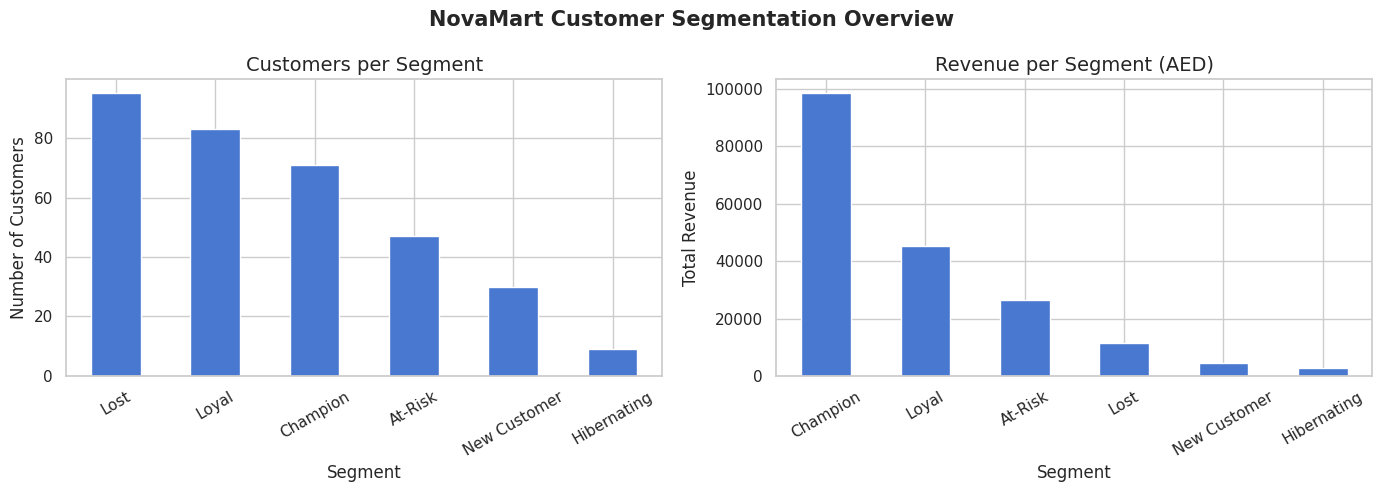

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Customer count per segment
summary.sort_values('customer_count', ascending=False).plot(
    kind='bar',
    x='Segment',
    y='customer_count',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Customers per Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Total revenue per segment
summary.sort_values('total_revenue', ascending=False).plot(
    kind='bar',
    x='Segment',
    y='total_revenue',
    ax=axes[1],
    legend=False
)
axes[1].set_title('Revenue per Segment (AED)')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('NovaMart Customer Segmentation Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



> The largest segment by customer count is Lost with 95 customers, but it is not the highest-revenue segment. The highest-revenue segment is Champion, which contributes 52.1% of total revenue despite having only 71 customers. This shows that customer value is not evenly distributed across the base, and NovaMart depends heavily on a smaller group of high-value customers, which creates concentration risk if these customers are not retained

---
# 💡 Section 5 — Business Insights & Export

---

##  5.1 — Answer the Business Questions


In [ ]:

print('=== Key Metrics for Business Questions ===')
print()
print('Total customers analysed         :', len(rfm))
print('Total revenue in dataset         :', f"AED {df['order_value'].sum():,.0f}")
print()
print('--- Segments ---')
print(summary[['Segment','customer_count','revenue_share_%','avg_monetary']].to_string(index=False))

=== Key Metrics for Business Questions ===

Total customers analysed         : 335
Total revenue in dataset         : AED 188,990

--- Segments ---
     Segment  customer_count  revenue_share_%  avg_monetary
    Champion              71             52.1       1387.09
       Loyal              83             24.0        546.87
     At-Risk              47             13.9        559.69
        Lost              95              6.1        121.92
New Customer              30              2.3        144.79
 Hibernating               9              1.5        320.52



> The segment with the highest number of customers is Lost with 95 customers. The segment that generates the most revenue is Champion, contributing 52.1% of total revenue, while Lost contributes only 6.1%. These are not the same segment, and this gap shows that NovaMart’s revenue is driven much more by customer quality and spending power than by customer count alone



> (20% × At-Risk count) × (Loyal avg_monetary − At-Risk avg_monetary)

> the estimated revenue gain is:
(20% × 47) × (546.87 - 559.69)
= 9.4 × (-12.82)
= -120.51 AED
This result is negative, which means that in this dataset the average monetary value of At-Risk customers (AED 559.69) is actually slightly higher than that of Loyal customers (AED 546.87). So moving 20% of At-Risk customers to the Loyal segment would not create an immediate monetary gain based on average segment value alone, although it could still help protect future revenue and reduce churn risk



> The most urgent segment to act on this week is At-Risk. This group contains 47 customers and contributes 13.9% of total revenue, which is a meaningful share for a segment that is already showing signs of disengagement. I would recommend a reactivation campaign with a limited-time personalised offer, such as a reminder email or retargeting ad featuring products from categories they previously purchased, because this segment still has relatively high average value and is more recoverable than Lost customers



> If NovaMart can run only one campaign this week, the best segment to target is At-Risk. This segment is large enough to matter (47 customers) and still valuable, contributing 13.9% of total revenue with an average monetary value of AED 559.69, which is higher than the Loyal segment. The best channel would be Email, because it is suitable for personalised reactivation messaging at low cost, and the message should focus on urgency and return, such as a limited-time offer, tailored recommendations, or a “we miss you” campaign designed to bring previously active customers back before they move into the Lost segment



> The biggest risk if NovaMart does nothing to maintain its Champion segment is revenue concentration. Champion customers account for 52.1% of total revenue, so losing even a small portion of them would have a serious impact on sales performance. One AI-powered strategy to protect this segment is a churn prediction and personalised recommendation system that identifies early signs of disengagement and automatically delivers tailored offers, product suggestions, or loyalty rewards before these high-value customers reduce their activity

## 5.2 — Export Files for Power BI


In [ ]:
# File 1: Clean merged transactions (for Sales Overview page)
df.to_csv('transactions_clean.csv', index=False)
print('✅ Exported: transactions_clean.csv  —', len(df), 'rows')

# File 2: Full RFM output per customer (for Segmentation page)
rfm.to_csv('rfm_output.csv', index=False)
print('✅ Exported: rfm_output.csv          —', len(rfm), 'rows')

# File 3: Segment summary table (for KPI cards and summary visuals)
summary.to_csv('rfm_summary.csv', index=False)
print('✅ Exported: rfm_summary.csv         —', len(summary), 'rows')

print()
print('=== Columns in each file ===')
print('transactions_clean:', list(df.columns))
print('rfm_output        :', list(rfm.columns))
print('rfm_summary       :', list(summary.columns))

✅ Exported: transactions_clean.csv  — 1891 rows
✅ Exported: rfm_output.csv          — 335 rows
✅ Exported: rfm_summary.csv         — 6 rows

=== Columns in each file ===
transactions_clean: ['transaction_id', 'customer_id', 'date', 'order_value', 'product_category', 'is_return', 'signup_date', 'region', 'gender', 'age_group', 'acquisition_channel', 'loyalty_tier']
rfm_output        : ['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'Segment']
rfm_summary       : ['Segment', 'customer_count', 'avg_recency', 'avg_frequency', 'avg_monetary', 'total_revenue', 'revenue_share_%']



>Champion — protect with VIP rewards, exclusive offers, and personalised recommendations
Loyal — increase basket size through bundles and cross-sell campaigns.
New Customer — encourage the second purchase with welcome offers and follow-up messaging
At-Risk — run reactivation campaigns with urgency-based personalised discounts
Hibernating — test low-cost reminder campaigns and re-engagement content
Lost — use selective win-back campaigns, but keep budget controlled due to lower expected return